## **Problem Statement**

Bangalore is one of India's fastest-growing metropolitan cities, with a diverse and rapidly changing real estate market. Property prices vary considerably due to factors such as location, total area, number of bedrooms, bathrooms, property type, and other property characteristics. This variation makes it challenging for buyers, sellers, and real estate professionals to accurately estimate the fair market value of a property.

A data-driven pricing system can help overcome this challenge by estimating property prices based on historical housing data. Such a system can assist buyers in making informed purchasing decisions, help sellers set competitive prices, and support real estate businesses in providing consistent property valuations.

The objective of this project is to analyze the Bangalore housing market, identify the key factors influencing house prices, and develop a predictive model capable of estimating the market value of residential properties while generating meaningful business insights.

## **Business Objective**

The proposed solution should enable stakeholders to estimate the market value of residential properties more accurately using historical housing data. It should support buyers in making informed purchasing decisions, assist sellers in setting competitive property prices, and help real estate businesses perform consistent property valuations.

Additionally, the solution should provide insights into the factors that have the greatest influence on house prices, allowing stakeholders to better understand market trends and make more informed, data-driven decisions.


# Initial Inspection

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/Bengaluru_House_Data.csv')
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [ ]:
data.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [ ]:
data.sample(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
1911,Plot Area,Ready To Move,Hongasandra,2 Bedroom,NaN,680,2.0,0.0,42.00
8269,Super built-up Area,Ready To Move,Hegde Nagar,2 BHK,Inaadd,1340,2.0,2.0,72.00
557,Super built-up Area,21-Dec,Kanakpura Road,1 BHK,PrarePa,525,1.0,1.0,27.25
11455,Super built-up Area,Ready To Move,Hormavu,2 BHK,ARureig,1075,2.0,1.0,53.70
12919,Super built-up Area,Ready To Move,Kanakpura Road,3 BHK,PuandHi,1622,3.0,NaN,95.00
12384,Super built-up Area,Ready To Move,Hormavu,2 BHK,NaN,1020,2.0,2.0,45.75
2267,Super built-up Area,Ready To Move,Someshwara Layout,4 BHK,NaN,1200,4.0,3.0,169.00
1539,Built-up Area,18-Dec,Whitefield,2 BHK,NaN,1192,2.0,1.0,71.00
12011,Built-up Area,Ready To Move,9th Phase JP Nagar,8 BHK,NaN,800,8.0,NaN,140.00
4568,Super built-up Area,Ready To Move,Yelahanka New Town,3 BHK,SPllain,1541,3.0,3.0,80.00


In [ ]:
data.duplicated().sum()

np.int64(529)

In [ ]:
!pip install missingno

<Axes: >

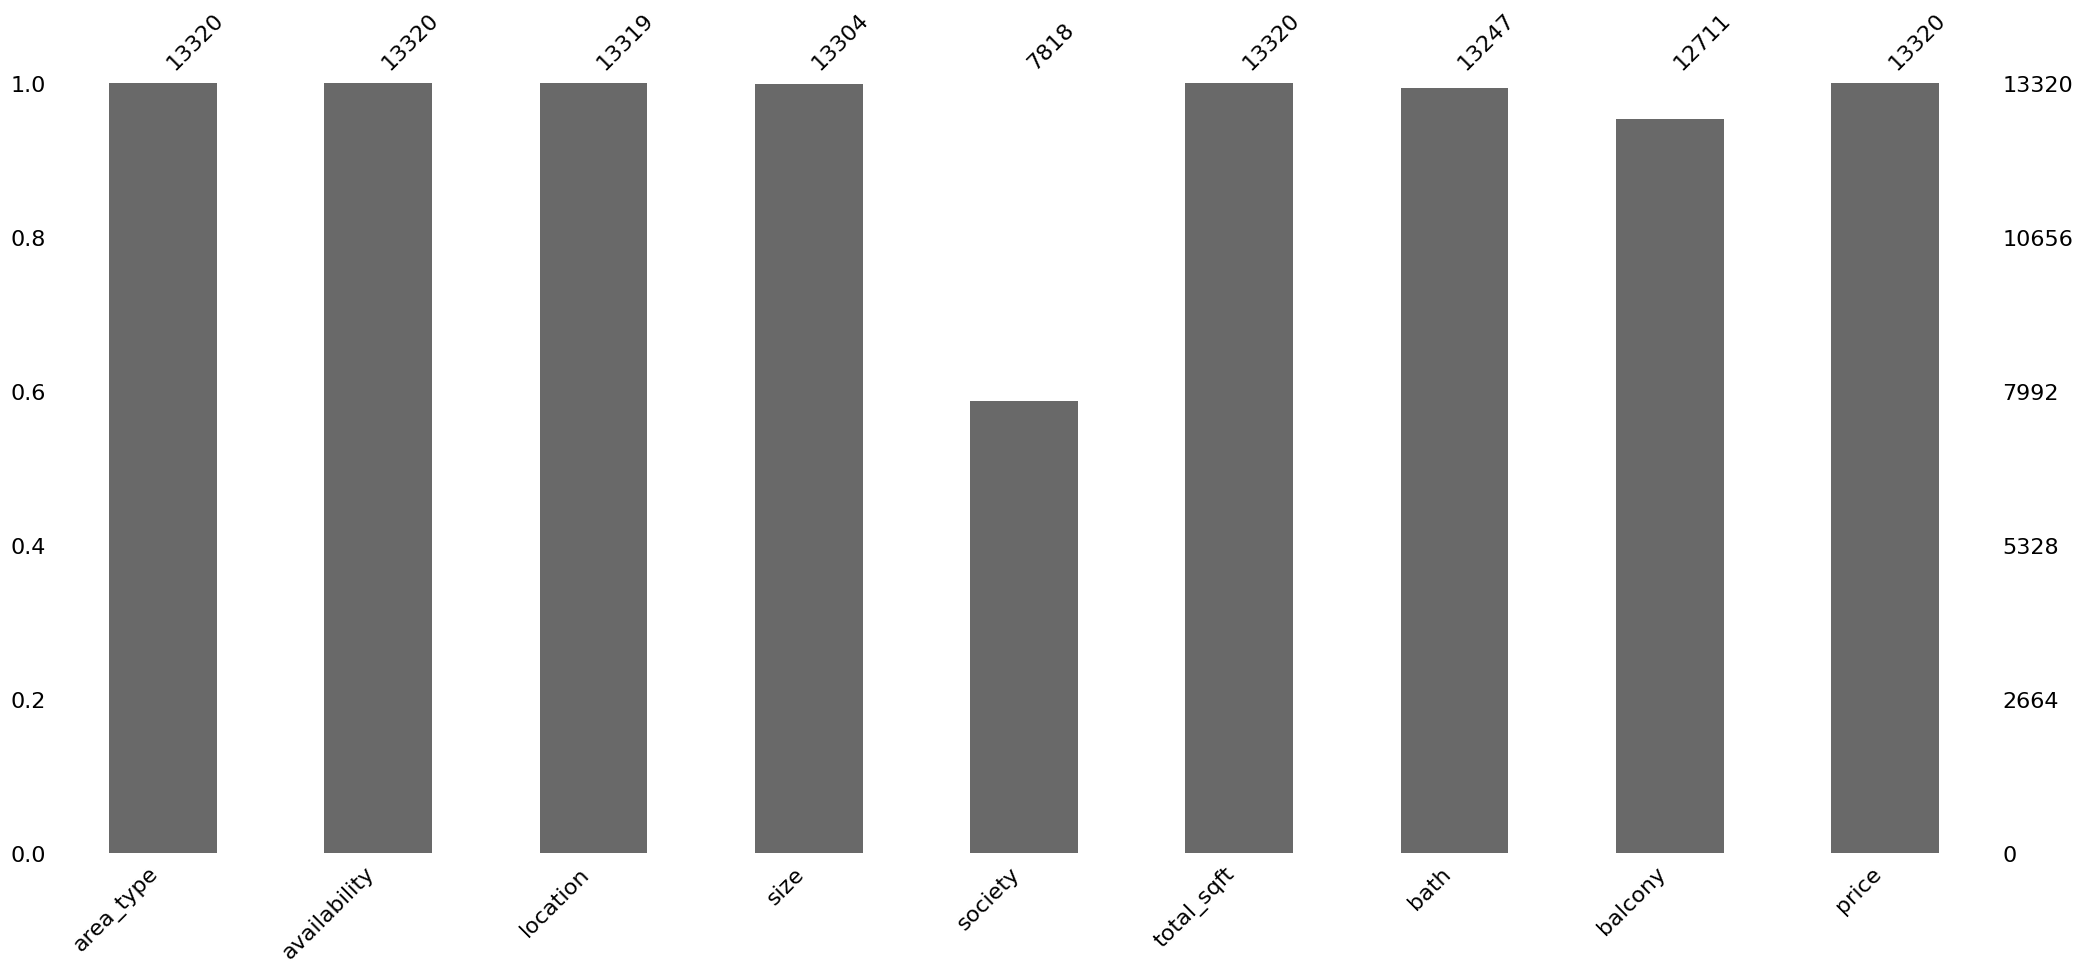

In [ ]:
import missingno as msno
msno.bar(data)

<Axes: >

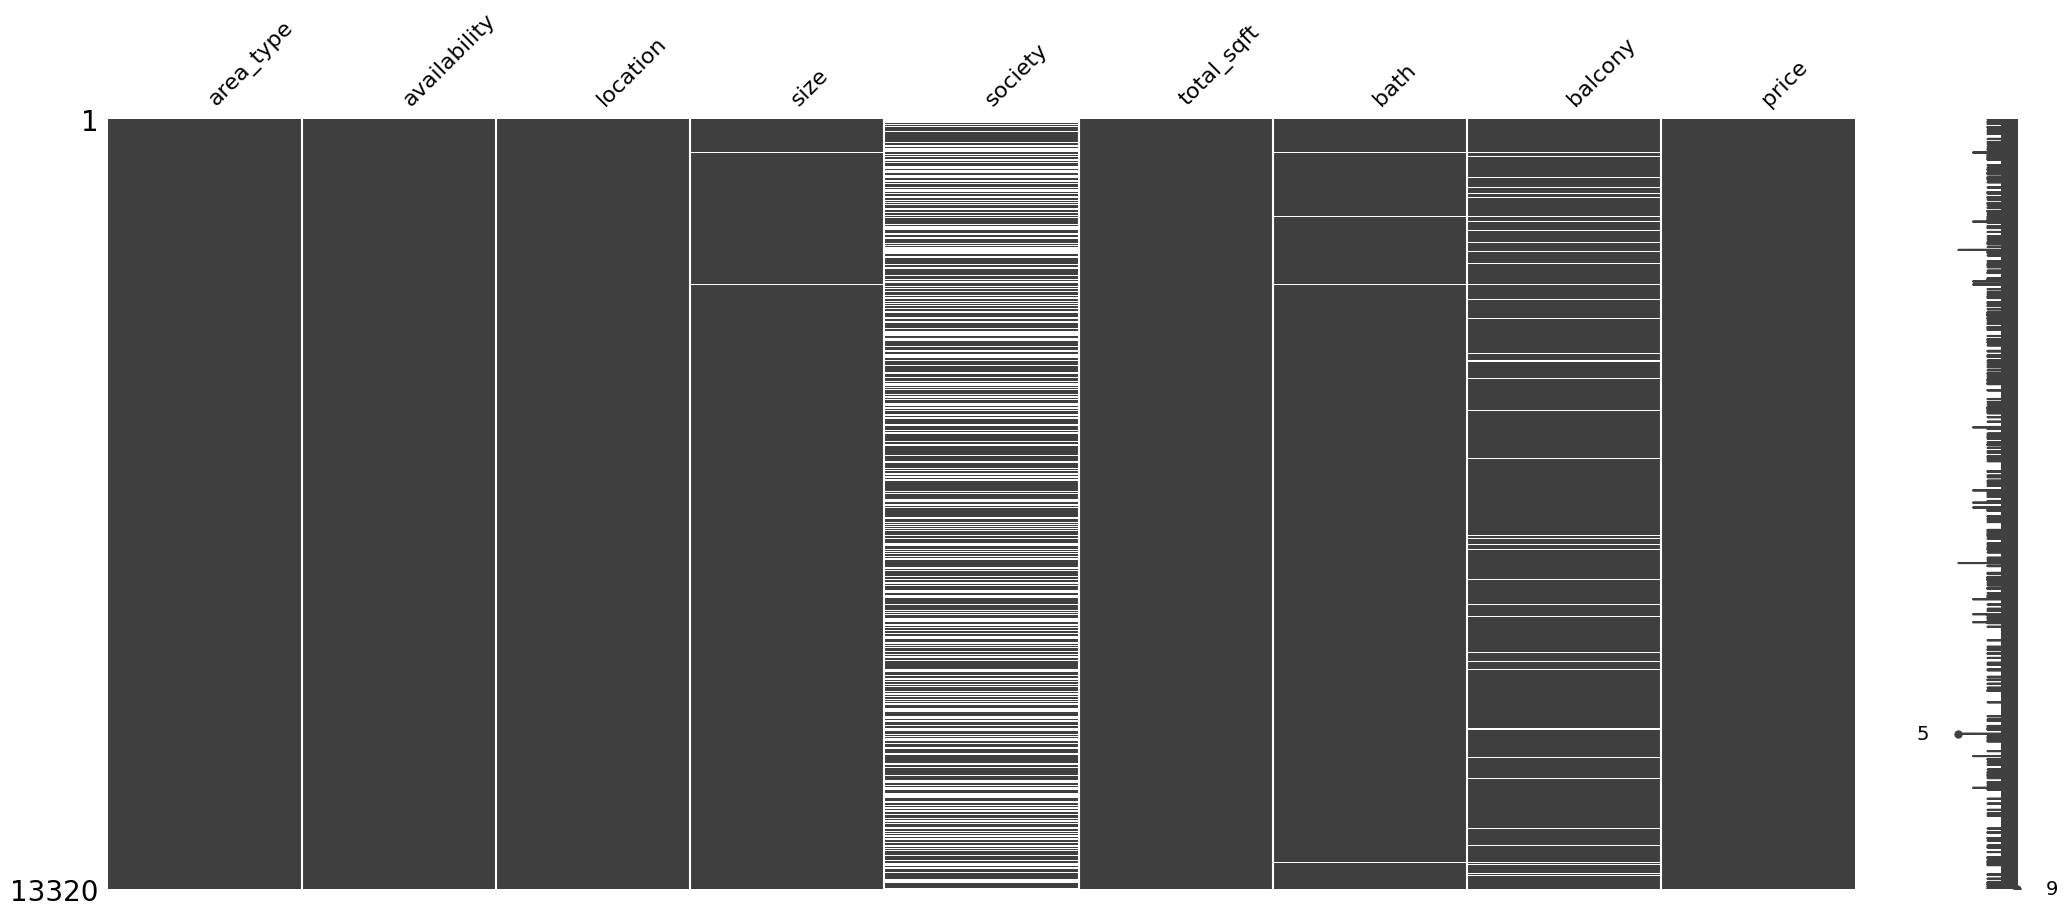

In [ ]:
msno.matrix(data)

In [ ]:
data[data['size'].isnull()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
579,Plot Area,Immediate Possession,Sarjapur Road,NaN,Asiss B,1200 - 2400,NaN,NaN,34.185
1775,Plot Area,Immediate Possession,IVC Road,NaN,Orana N,2000 - 5634,NaN,NaN,124.000
2264,Plot Area,Immediate Possession,Banashankari,NaN,NaN,2400,NaN,NaN,460.000
2809,Plot Area,Immediate Possession,Sarjapur Road,NaN,AsdiaAr,1200 - 2400,NaN,NaN,28.785
2862,Plot Area,Immediate Possession,Devanahalli,NaN,Ajleyor,1500 - 2400,NaN,NaN,46.800
5333,Plot Area,Immediate Possession,Devanahalli,NaN,Emngs S,2100 - 5405,NaN,NaN,177.115
6423,Plot Area,Immediate Possession,Whitefield,NaN,SRniaGa,2324,NaN,NaN,26.730
6636,Plot Area,Immediate Possession,Jigani,NaN,S2enste,1500,NaN,NaN,25.490
6719,Plot Area,Immediate Possession,Hoskote,NaN,SJowsn,800 - 2660,NaN,NaN,28.545
7680,Plot Area,Immediate Possession,Kasavanhalli,NaN,NaN,5000,NaN,NaN,400.000


## **Dataset Description**

This project uses the Bangalore House Price Dataset, which contains information on residential properties listed for sale in Bangalore, India. Each record represents a single property and includes details describing its characteristics along with its corresponding selling price.

The dataset consists of 13,320 residential property records and 9 features, including property location, area type, availability status, size, total built-up area, number of bathrooms, balconies, society information, and the **target variable**, price.

The dataset consists of 6 categorical features and 3 numerical features. Several features contain missing values, with the society column having the highest proportion of missing observations. Missing values are also present in the location, size, bath, and balcony columns. There are 529 duplicate rows in dataset. This dataset use memory of 936.7+ KB.

### **Key Takeaways**

- The dataset contains **13,320 residential property records** and **9 features**.
- It includes **6 categorical features** and **3 numerical features**.
- The target variable is **price**, which represents the selling price of a residential property.
- Several features contain missing values, with the **society** column having the highest number of missing observations.
- Missing values are also present in the **location**, **size**, **bath**, and **balcony** features, indicating that data preprocessing will be required before model building.
- **529 duplicate rows**
- This dataset use** memory of 936.7+ KB**.

### **Feature Description Table**

| Feature      | Data Type   | Description                                             |
| ------------ | ----------- | ------------------------------------------------------- |
| area_type    | Categorical (object) | Type of property area (e.g., Super built-up, Plot Area) |
| availability | Categorical (object) | Availability status of the property                     |
| location     | Categorical (object) | Locality where the property is situated                 |
| size         | Categorical (object) | Property size in terms of BHK/Bedroom                   |
| society      | Categorical (object) | Name of the housing society                             |
| total_sqft   | Mixed  (object)     | Total built-up area of the property                     |
| bath         | Numerical   (float) | Number of bathrooms                                     |
| balcony      | Numerical   (float) | Number of balconies                                     |
| price        | Numerical   (float) | Property price (in lakhs)                               |


In [ ]:
data.nunique()

,0
area_type,4
availability,81
location,1305
size,31
society,2688
total_sqft,2117
bath,19
balcony,4
price,1994


## **Unique Value Summary**

| Feature          | Unique Values | Observation                                                                                                                                                    |
| ---------------- | ------------: | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **area_type**    |             4 | Low cardinality; suitable for categorical encoding.                                                                                                            |
| **availability** |            81 | Moderate cardinality; requires further inspection to understand different availability formats.                                                                |
| **location**     |          1305 | Very high cardinality; likely contains rare locations that may need grouping.                                                                                  |
| **size**         |            31 | Moderate cardinality; values require inspection to understand different property size formats.                                                                 |
| **society**      |          2688 | Extremely high cardinality; may have limited predictive value and requires careful evaluation.                                                                 |
| **total_sqft**   |          2117 | Very high number of unique values; since this is stored as an object, it should be examined for inconsistent formats before conversion to a numerical feature. |
| **bath**         |            19 | Low cardinality; represents discrete numerical values.                                                                                                         |
| **balcony**      |             4 | Very low cardinality; represents discrete numerical values.                                                                                                    |
| **price**        |          1994 | Continuous target variable with a large number of unique values, which is expected in a regression problem.                                                    |


# Univariate Analysis

## area type

**Question** - What types of residential property areas are available in the Bangalore housing market, how are they distributed, and does this feature present any data quality issues before modeling?

In [ ]:
data["area_type"].isnull().sum()

np.int64(0)

In [ ]:
data.area_type.value_counts()

,count
area_type,
Super built-up Area,8790
Built-up Area,2418
Plot Area,2025
Carpet Area,87


<Axes: xlabel='area_type', ylabel='count'>

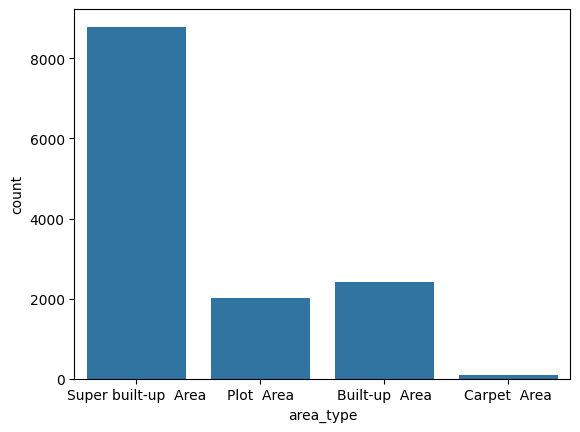

In [ ]:
sns.countplot(data=data,x='area_type')

In [ ]:
data["area_type"].value_counts(normalize=True)*100

,proportion
area_type,
Super built-up Area,65.990991
Built-up Area,18.153153
Plot Area,15.202703
Carpet Area,0.653153


### **Observations**

* The feature contains 4 unique categories.
* Super built-up Area dominates the dataset (≈66%).
* Carpet Area is underrepresented (<1%).
* No missing values or apparent inconsistencies were found.
* The feature is a low-cardinality categorical variable.
* Although the distribution is imbalanced, this does not represent a data quality issue because area_type is an explanatory feature rather than the target variable




### **Business Insight**

The Bangalore housing listings in this dataset are predominantly classified as Super built-up Area, suggesting that this property type represents the majority of the residential market covered by the dataset. Consequently, model predictions for Carpet Area properties may be less reliable due to their limited representation.

### **Preprocessing Decision**

Since most of the machine learning models cannot directly process categorical string values, this feature will be converted into a numerical representation using an appropriate categorical encoding technique before model training.

## **Availability**



In [ ]:
data["availability"].unique()

array(['19-Dec', 'Ready To Move', '18-May', '18-Feb', '18-Nov', '20-Dec',
       '17-Oct', '21-Dec', '19-Sep', '20-Sep', '18-Mar', '20-Feb',
       '18-Apr', '20-Aug', '18-Oct', '19-Mar', '17-Sep', '18-Dec',
       '17-Aug', '19-Apr', '18-Jun', '22-Dec', '22-Jan', '18-Aug',
       '19-Jan', '17-Jul', '18-Jul', '21-Jun', '20-May', '19-Aug',
       '18-Sep', '17-May', '17-Jun', '21-May', '18-Jan', '20-Mar',
       '17-Dec', '16-Mar', '19-Jun', '22-Jun', '19-Jul', '21-Feb',
       'Immediate Possession', '19-May', '17-Nov', '20-Oct', '20-Jun',
       '19-Feb', '21-Oct', '21-Jan', '17-Mar', '17-Apr', '22-May',
       '19-Oct', '21-Jul', '21-Nov', '21-Mar', '16-Dec', '22-Mar',
       '20-Jan', '21-Sep', '21-Aug', '14-Nov', '19-Nov', '15-Nov',
       '16-Jul', '15-Jun', '17-Feb', '20-Nov', '20-Jul', '16-Sep',
       '15-Oct', '15-Dec', '16-Oct', '22-Nov', '15-Aug', '17-Jan',
       '16-Nov', '20-Apr', '16-Jan', '14-Jul'], dtype=object)

In [ ]:
data["availability"].nunique()

81

In [ ]:
data["availability"].isnull().sum()

np.int64(0)

In [ ]:
data["availability"].value_counts()

,count
availability,
Ready To Move,10581
18-Dec,307
18-May,295
18-Apr,271
18-Aug,200
...,...
16-Oct,1
17-Jan,1
16-Nov,1


In [ ]:
# Categorize availability into two groups

availability_summary = (
    data.assign(
        Availability_Type=np.where(
            data["availability"].isin(["Ready To Move", "Immediate Possession"]),
            "Ready / Immediate Possession",
            "Date-based Possession"
        )
    )["Availability_Type"]
    .value_counts()
    .rename_axis("Availability Type")
    .reset_index(name="Count")
)

availability_summary["Percentage"] = (
    availability_summary["Count"] / len(data) * 100
).round(2)

availability_summary

,Availability Type,Count,Percentage
0,Ready / Immediate Possession,10597,79.56
1,Date-based Possession,2723,20.44


### **Observations**

* No missing values.
* 81 unique values are present.
* The feature contains mixed representations of availability information.
* Availability is recorded using both textual labels and possession dates.


### **Business Interpretation**

The availability feature represents the possession status of a property and contains two types of information:

1. Immediate availability (Ready To Move and Immediate Possession)
2. Expected possession dates (e.g., 18-Dec, 19-May, 21-Jun)

Approximately 80% of the properties are already available for possession, while only 20% represent future possession dates. This suggests that the dataset is predominantly composed of ready-to-move properties.

The feature may contain useful information because the possession status of a property can influence buyer preference and, consequently, its market price. However, its predictive value should be verified during bivariate analysis.

### **Preprocessing Decision**

The feature requires standardization before modeling. The final representation of this feature will be decided after evaluating its relationship with the target variable during bivariate analysis.

## location

In [ ]:
data["location"].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'Havanur extension', 'Abshot Layout'], dtype=object)

In [ ]:
data["location"].describe()

,location
count,13319
unique,1305
top,Whitefield
freq,540


In [ ]:
loc_count = data["location"].value_counts()
loc_count

,count
location,
Whitefield,540
Sarjapur Road,399
Electronic City,302
Kanakpura Road,273
Thanisandra,234
...,...
3rd Stage Raja Rajeshwari Nagar,1
Chuchangatta Colony,1
"Electronic City Phase 1,",1


In [ ]:
loc_count.head(20)

,count
location,
Whitefield,540
Sarjapur Road,399
Electronic City,302
Kanakpura Road,273
Thanisandra,234
Yelahanka,213
Uttarahalli,186
Hebbal,177
Marathahalli,175


In [ ]:
(loc_count == 1).sum()/loc_count.shape[0]*100

np.float64(36.7816091954023)

In [ ]:
(loc_count <= 5).sum()/loc_count.shape[0]*100

np.float64(70.49808429118774)

In [ ]:
(loc_count <= 10).sum()/loc_count.shape[0]*100

np.float64(81.53256704980842)

In [ ]:
# Finding duplicate names after standardization
location_df = (
    data["location"]
    .dropna()
    .to_frame()
)


location_df["clean"] = (
    location_df["location"]
    .str.strip()
    .str.lower()
)

duplicates = (
    location_df
    .groupby("clean")["location"]
    .unique()
)

print("total unique locations are :",duplicates.shape[0])

duplicates = duplicates[duplicates.apply(len) > 1]

duplicates


total unique locations are : 1283


,location
clean,
anand nagar,"[Anand Nagar, Anand nagar]"
anekal,"[Anekal, Anekal]"
banaswadi,"[Banaswadi, Banaswadi]"
basavangudi,"[Basavangudi, Basavangudi]"
beml layout 5th stage,"[BEML Layout 5th stage, BEML Layout 5th Stage]"
bhoganhalli,"[Bhoganhalli, Bhoganhalli]"
devarabeesana halli,"[ Devarabeesana Halli, Devarabeesana Halli]"
devarachikkanahalli,"[Devarachikkanahalli, Devarachikkanahalli]"
electronic city,"[Electronic City, Electronic City]"


### **Observations**

* The location feature contains 1 missing value, 13,319 non-missing observations and 1,305 unique locations, making it the highest-cardinality categorical feature in the dataset.
* After standardizing the location names (removing leading/trailing spaces and converting text to lowercase), the number of unique locations decreased from 1,305 to 1,283.
* This indicates that 21 categories were duplicated due to inconsistent capitalization and whitespace.
* The distribution of locations is highly skewed, with a small number of locations appearing frequently and most locations occurring only a few times.
* Approximately 36.78% of locations appear only once.
* Approximately 70.50% of locations appear 5 or fewer times.
* Approximately 81.53% of locations appear 10 or fewer times.

### **Business Interpretation**

Property location is expected to be one of the most influential factors affecting house prices. However, the large number of unique locations and the presence of many infrequently occurring categories increase the complexity of the feature. Rare locations may not provide sufficient information for the model to learn reliable pricing patterns and may increase the risk of overfitting if encoded directly.

### **Preprocessing Decision**

Before model training, location names will be standardized to eliminate inconsistencies caused by capitalization and whitespace. Subsequently, infrequently occurring locations will be grouped into an "Other" category based on an appropriate frequency threshold. This will reduce the feature's cardinality while preserving its predictive information.

## Size

In [ ]:
data['size'].isnull().sum()

np.int64(16)

In [ ]:
data["size"].value_counts()

,count
size,
2 BHK,5199
3 BHK,4310
4 Bedroom,826
4 BHK,591
3 Bedroom,547
1 BHK,538
2 Bedroom,329
5 Bedroom,297
6 Bedroom,191


Although the original feature is named size, it actually represents the number of rooms (e.g., BHK, Bedroom, RK) rather than a physical measurement. To simplify the analysis and modeling process, the numerical component is extracted into a new feature named bhk, while the original size column is retained for reference.

In [ ]:
# Extract the numerical part from the 'size' column
data["bhk"] = (
    data["size"]
    .str.extract(r"(\d+)")
    .astype(float)
)

data['bhk']

,bhk
0,2.0
1,4.0
2,3.0
3,3.0
4,2.0
...,...
13315,5.0
13316,4.0
13317,2.0
13318,4.0


In [ ]:
data['bhk'].value_counts()

,count
bhk,
2.0,5528
3.0,4857
4.0,1417
1.0,656
5.0,356
6.0,221
7.0,100
8.0,89
9.0,54


<Axes: xlabel='bhk'>

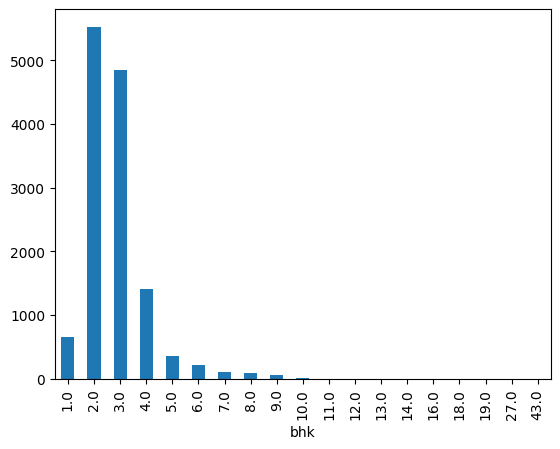

In [ ]:
data["bhk"].value_counts().sort_index().plot.bar()

### **Observations**
* 16 missing values are present.
* Most properties are 2 BHK (5,528) and 3 BHK (4,857).
* Properties with more than 6 BHK are relatively uncommon.
* A few observations contain extremely high BHK values (e.g., 19, 27, and 43), which require further investigation.

### **Business Interpretation**

* The Bangalore housing market represented in this dataset is dominated by 2 BHK and 3 BHK residential properties.
* Large residential properties constitute only a small proportion of the market.
* Extremely high BHK values may represent luxury properties, apartment buildings, or potential data quality issues and should be verified before modeling.

### **Preprocessing Decision**

Missing values will be handled during the preprocessing stage. Observations with unusually high BHK values will be investigated further before deciding whether they should be retained, transformed, or removed as outliers.

## Society

In [ ]:
data["society"].isnull().sum()

np.int64(5502)

In [ ]:
data['society'].nunique()

2688

### **Observations**

* The society feature contains 5,502 missing values (≈41.3%).
* It has 2,688 unique categories, making it an extremely high-cardinality categorical feature.
* The combination of high missingness and high cardinality reduces its suitability for predictive modeling.

### **Business Interpretation**

* A housing society may influence property prices because it reflects the residential community and available amenities.
* However, the feature is incomplete for a large proportion of properties and is unlikely to generalize well due to the large number of unique society names.

### **Preprocessing Decision**

The society feature either will be removed from the dataset or we will use missing indicator for this column before model training. This decision is based on its high proportion of missing values, extremely high cardinality, and limited ability to generalize to unseen data. Moreover, much of the location-related information is already captured by the location feature, making society less valuable relative to its complexity.

## Bath

In [ ]:
data['bath'].describe()

,bath
count,13247.000000
mean,2.692610
std,1.341458
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,40.000000


In [ ]:
data['bath'].isnull().sum()

np.int64(73)

In [ ]:
data['bath'].nunique()

19

In [ ]:
data['bath'].value_counts()

,count
bath,
2.0,6908
3.0,3286
4.0,1226
1.0,788
5.0,524
6.0,273
7.0,102
8.0,64
9.0,43


<Axes: xlabel='bath', ylabel='Count'>

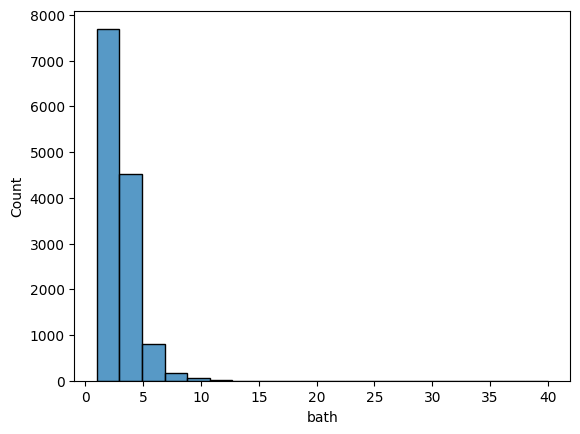

In [ ]:
sns.histplot(data["bath"], bins=20)

<Axes: xlabel='bath'>

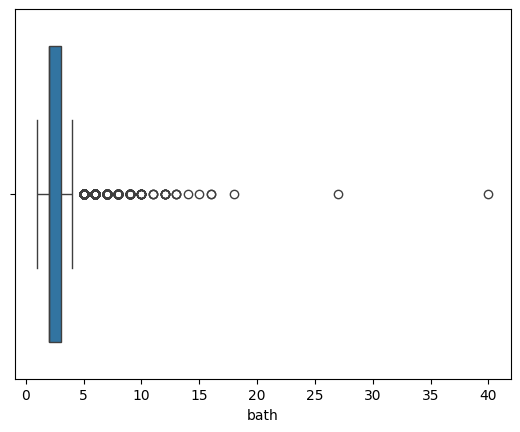

In [ ]:
sns.boxplot(x=data["bath"])

### **Observations**

* The bath feature contains 13,247 non-missing observations and 73 missing values.
* It is stored as a float64 data type but contains only whole-number values (no fractional bathrooms were observed).
* The number of bathrooms ranges from 1 to 40, with a median of 2 and a mean of 2.69, indicating that most properties have 2–3 bathrooms.
* The distribution is positively (right) skewed, with a small number of properties having a very high number of bathrooms.
* The boxplot identifies several potential outliers, particularly for properties with more than 5 bathrooms, which require further investigation before deciding whether they are genuine luxury properties or data quality issues.

### **Business Interpretation**

* Most residential properties in the dataset have 2–3 bathrooms, which is consistent with typical urban housing.
* Properties with a large number of bathrooms are relatively uncommon and are likely to represent luxury homes or large residential buildings.


### **Preprocessing Decision**

Missing values will be handled during the preprocessing stage. Potential outliers will be investigated in conjunction with related features such as BHK and total_sqft before deciding whether any treatment is required.

## balcony

In [ ]:
data['balcony'].dtype

dtype('float64')

In [ ]:
data['balcony'].describe()

,balcony
count,12711.000000
mean,1.584376
std,0.817263
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,3.000000


In [ ]:
data['balcony'].isnull().sum()

np.int64(609)

In [ ]:
data['balcony'].nunique()

4

In [ ]:
data['balcony'].value_counts()

,count
balcony,
2.0,5113
1.0,4897
3.0,1672
0.0,1029


<Axes: xlabel='balcony'>

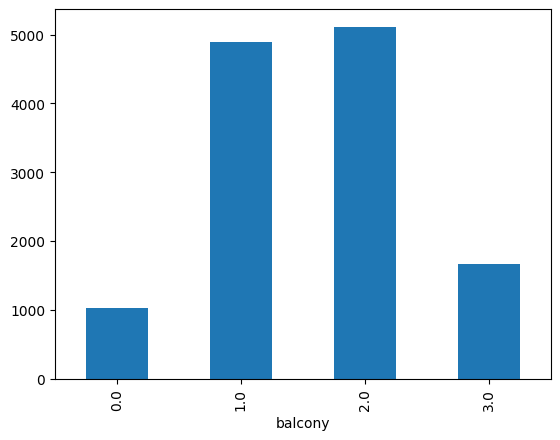

In [ ]:
data['balcony'].value_counts().sort_index().plot(kind='bar')

### **Observations**

* The balcony feature contains 12,711 non-missing observations and 609 missing values.
* It is stored as a float64 data type but contains only whole-number values ranging from 0 to 3.
* The feature has only 4 unique values, making it a low-cardinality discrete numerical feature.
* Most properties have 1 or 2 balconies.
* Properties with 3 balconies are relatively uncommon, while properties with no balcony are the least frequent.

### **Business Interpretation**

* The majority of residential properties in the dataset have one or two balconies, which reflects the typical design of urban apartments and independent houses.
* Although the number of balconies may contribute to a property's attractiveness and price, its influence is expected to be smaller than features such as location, total square feet, BHK, and number of bathrooms.

### **Preprocessing Decision**

Missing values will be handled during the preprocessing stage. Since the feature already contains valid discrete numerical values with a small range (0–3), no additional transformation is required.

## total_sqft

In [ ]:
data['total_sqft'].describe()

,total_sqft
count,13320
unique,2117
top,1200
freq,843


In [ ]:
data['total_sqft'].sample(50)

,total_sqft
9623,1450
121,2061
8290,1100
11075,3000
8313,1660
2917,900
8338,1100
11766,1635
3526,1616
9841,1683


In [ ]:
range_values = data.loc[
    data["total_sqft"].str.contains("-", na=False),
    "total_sqft"
]

range_values.shape

(201,)

In [ ]:
numeric_values = data.loc[
    data["total_sqft"].str.fullmatch(
    r"\d+(\.\d+)?",
    na=False
), "total_sqft" ]

numeric_values.shape

(13073,)

In [ ]:
unit_values = data.loc[
    data["total_sqft"].str.contains(r"[A-Za-z]", na=False),
    "total_sqft"
]

unit_values.shape

(46,)

In [ ]:
201+13073+46

13320

### **Observations**



*   The total_sqft column contains 13,320 records, with 2,117 unique values. The most frequent value is 1200, occurring 843 times.



*  Based on the format analysis:


| Type of value                |      Count | Percentage |
| ---------------------------- | ---------: | ---------: |
| Numeric values               |     13,073 | **98.15%** |
| Range values                 |        201 |  **1.51%** |
| Values containing units/text |         46 |  **0.35%** |
| **Total**                    | **13,320** |   **100%** |


### **Business Interpretation**

* total_sqft represents the total area of the property, so it is an important factor influencing house prices.
* 98.15% of values are directly numeric, while a small portion is recorded as ranges or with units.



### **Preprocessing Decision**

* Numeric values: Keep as they are.
* Range values: Replace with the midpoint of the range.
* Unit-based values: Convert all areas to square feet.
* Convert the entire column to a numeric datatype after cleaning.

# Preprocessing

## total_sqft

In [ ]:
import re

def clean_total_sqft(X):

    X = X.copy()
    s = X["total_sqft"].astype(str).str.strip()

    # Start with NaN
    result = pd.Series(np.nan, index=s.index, dtype=float)


    # --------------------------------------------------
    # 1. Numeric values
    # --------------------------------------------------

    numeric_mask = s.str.fullmatch(
        r"\d+(\.\d+)?",
        na=False
    )

    result.loc[numeric_mask] = (
        s.loc[numeric_mask].astype(float)
    )


    # --------------------------------------------------
    # 2. Range values → midpoint
    # --------------------------------------------------

    range_mask = s.str.fullmatch(
        r"\d+(\.\d+)?\s*-\s*\d+(\.\d+)?",
        na=False
    )

    ranges = s.loc[range_mask].str.split("-", expand=True)

    result.loc[range_mask] = (
        ranges[0].astype(float) +
        ranges[1].astype(float)
    ) / 2


    # --------------------------------------------------
    # 3. Unit-based values → convert to sqft
    # --------------------------------------------------

    conversion_factors = {
        "Sq. Meter": 10.7639,
        "Sq. Yards": 9,
        "Acres": 43560,
        "Cents": 435.6,
        "Guntha": 1089,
        "Grounds": 2400,
        "Perch": 272.25
    }

    for unit, factor in conversion_factors.items():

        mask = s.str.fullmatch(
            rf"\d+(\.\d+)?\s*{re.escape(unit)}",
            na=False
        )

        values = (
            s.loc[mask]
            .str.extract(r"(\d+(?:\.\d+)?)")[0]
            .astype(float)
        )

        result.loc[mask] = values * factor


    # Return DataFrame
    return result.to_frame(name="total_sqft")

In [ ]:
from sklearn.preprocessing import FunctionTransformer

total_sqft_transformer = FunctionTransformer(
    clean_total_sqft
)

## Availability

In [ ]:
def clean_availability(X):
    X = X.copy()

    X["availability"] = np.where(
        X["availability"].isin(
            ["Ready To Move", "Immediate Possession"]
        ),
        "Ready / Immediate Possession",
        "Date-based Possession"
    )

    return X

In [ ]:
# def clean_availability(X):
#     return np.where(
#         X["availability"].isin(
#             ["Ready To Move", "Immediate Possession"]
#         ),
#         "Ready / Immediate Possession",
#         "Date-based Possession"
#     ).reshape(-1, 1)

In [ ]:
# def clean_availability(X):
#     availability = np.where(
#         X["availability"].isin(
#             ["Ready To Move", "Immediate Possession"]
#         ),
#         "Ready / Immediate Possession",
#         "Date-based Possession"
#     )

#     return pd.DataFrame(
#         availability,
#         index=X.index,
#         columns=["availability"]
#     )

In [ ]:
availability_transformer = FunctionTransformer(clean_availability)

## location

In [ ]:
def clean_location(X):
    X = X.copy()

    # Standardize location names
    X["location"] = (
        X["location"]
        .str.strip()
        .str.lower()
    )

    # Fill missing values with mode
    mode = X["location"].mode()[0]
    X["location"] = X["location"].fillna(mode)

    return X

In [ ]:
location_transformer = FunctionTransformer(clean_location)

## bhk

We will use mode to fill the missing values

**Why mode makes sense here**

* bhk takes discrete values: 1, 2, 3, 4...
* Mode gives a valid BHK category.
* It doesn't introduce a value that wasn't observed.
* Only 16 out of 13,320 values are missing, so the impact is negligible.

## bath

In [ ]:
data['bath'].mode()

,bath
0,2.0


We will use to fill nan values

**Why median imputation is appropriate for bath**



*   Mode is resistant to outliers
*   The actual mode is 2 which is also a valid and realistic number of bathrooms.
* Only 73 values are missing. That's about 0.55% of the dataset.
We don't need to discard those observations and lose potentially useful information from their other features.



## balcony

In [ ]:
data['balcony'].mode()

,balcony
0,2.0


In [ ]:
data['balcony'].value_counts()

,count
balcony,
2.0,5113
1.0,4897
3.0,1672
0.0,1029


# Data Quality Cleaning

In [ ]:
eda = data.copy()

In [ ]:
eda = eda.drop(columns=["society",'size'])
eda

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2.0
...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,3453,4.0,0.0,231.00,5.0
13316,Super built-up Area,Ready To Move,Richards Town,3600,5.0,NaN,400.00,4.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,1141,2.0,1.0,60.00,2.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4689,4.0,1.0,488.00,4.0


In [ ]:
eda['availability'] = clean_availability(eda[['availability']])

In [ ]:
eda['total_sqft'] = clean_total_sqft(eda[['total_sqft']])

In [ ]:
from sklearn.impute import SimpleImputer
categorical_numerical_features = ['bhk', 'bath','balcony']

imputer = SimpleImputer(
    strategy="most_frequent"
)

eda[categorical_numerical_features] = (
    imputer.fit_transform(
        eda[categorical_numerical_features]
    )
)

eda

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Date-based Possession,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Ready / Immediate Possession,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,Ready / Immediate Possession,Uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready / Immediate Possession,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready / Immediate Possession,Kothanur,1200.0,2.0,1.0,51.00,2.0
...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready / Immediate Possession,Whitefield,3453.0,4.0,0.0,231.00,5.0
13316,Super built-up Area,Ready / Immediate Possession,Richards Town,3600.0,5.0,2.0,400.00,4.0
13317,Built-up Area,Ready / Immediate Possession,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2.0
13318,Super built-up Area,Date-based Possession,Padmanabhanagar,4689.0,4.0,1.0,488.00,4.0


In [ ]:
eda['location'] = clean_location(eda[['location']])

In [ ]:
eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13320 non-null  object 
 3   total_sqft    13320 non-null  float64
 4   bath          13320 non-null  float64
 5   balcony       13320 non-null  float64
 6   price         13320 non-null  float64
 7   bhk           13320 non-null  float64
dtypes: float64(5), object(3)
memory usage: 832.6+ KB


In [ ]:
eda.describe()

,total_sqft,bath,balcony,price,bhk
count,1.332000e+04,13320.000000,13320.000000,13320.000000,13320.000000
mean,1.911597e+03,2.688814,1.603378,112.565627,2.802778
std,1.727690e+04,1.338754,0.803067,148.971674,1.294496
min,1.000000e+00,1.000000,0.000000,8.000000,1.000000
25%,1.100000e+03,2.000000,1.000000,50.000000,2.000000
50%,1.277250e+03,2.000000,2.000000,72.000000,3.000000
75%,1.680000e+03,3.000000,2.000000,120.000000,3.000000
max,1.306800e+06,40.000000,3.000000,3600.000000,43.000000


## Total_sqft

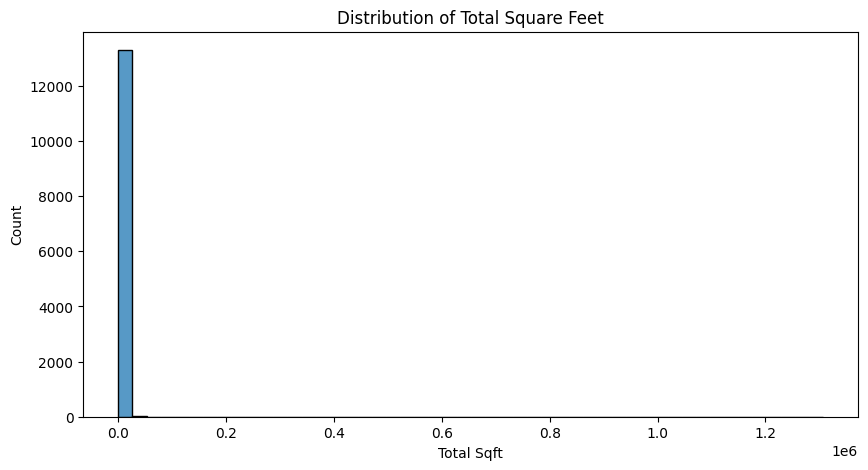

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda,
    x="total_sqft",
    bins=50
)

plt.title("Distribution of Total Square Feet")
plt.xlabel("Total Sqft")
plt.ylabel("Count")
plt.show()

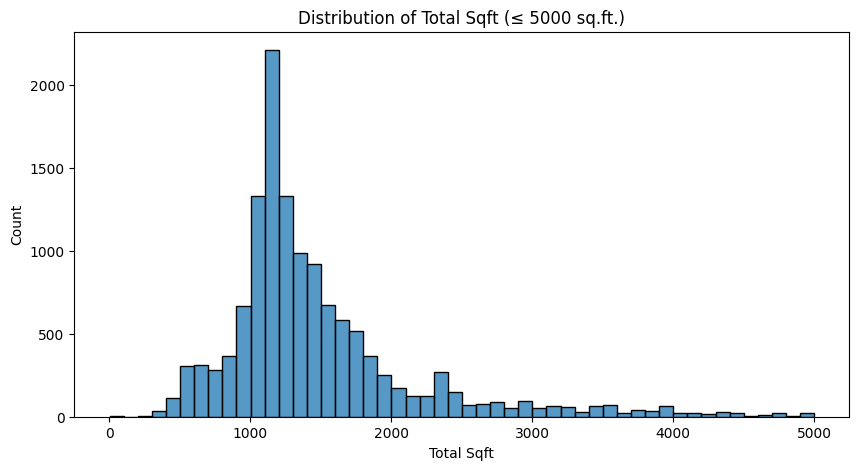

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda[eda["total_sqft"] <= 5000],
    x="total_sqft",
    bins=50
)

plt.title("Distribution of Total Sqft (≤ 5000 sq.ft.)")
plt.xlabel("Total Sqft")
plt.ylabel("Count")
plt.show()

In [ ]:
eda['total_sqft'].skew()

np.float64(61.38551346451967)

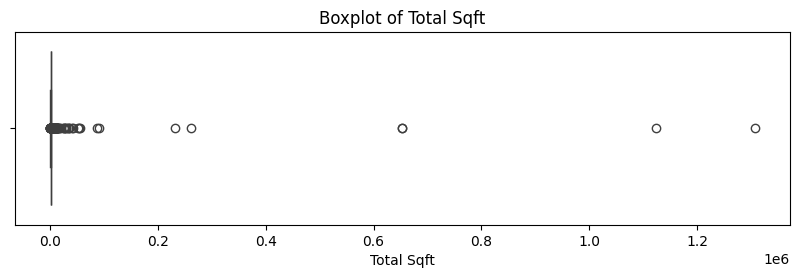

In [ ]:
plt.figure(figsize=(10, 2.5))

sns.boxplot(
    x=eda["total_sqft"]
)

plt.title("Boxplot of Total Sqft")
plt.xlabel("Total Sqft")
plt.show()

In [ ]:
Q1 = eda["total_sqft"].quantile(0.25)
Q3 = eda["total_sqft"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 1100.0
Q3: 1680.0
IQR: 580.0
Lower Bound: 230.0
Upper Bound: 2550.0


In [ ]:
outliers = eda[
    (eda["total_sqft"] < lower_bound) |
    (eda["total_sqft"] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Percentage:", len(outliers) / len(eda) * 100)

Number of outliers: 1193
Percentage: 8.956456456456456


In [ ]:
eda.nlargest(20, "total_sqft")[
    [
        "total_sqft",
        "bhk",
        "bath",
        "balcony",
        "price",
        "area_type",
        "location",
        "availability"
    ]
]

,total_sqft,bhk,bath,balcony,price,area_type,location,availability
1086,1306800.000,2.0,2.0,2.0,29.5,Plot Area,narasapura,Date-based Possession
648,1123031.250,9.0,9.0,2.0,265.0,Built-up Area,arekere,Ready / Immediate Possession
7001,653400.000,8.0,6.0,2.0,290.0,Plot Area,thyagaraja nagar,Ready / Immediate Possession
7607,653400.000,3.0,3.0,1.0,217.0,Plot Area,bommenahalli,Ready / Immediate Possession
11615,261360.000,3.0,2.0,0.0,80.0,Plot Area,arudi,Ready / Immediate Possession
1019,231303.600,1.0,1.0,0.0,110.0,Plot Area,marathi layout,Date-based Possession
6333,91040.400,2.0,2.0,0.0,200.0,Plot Area,harohalli,Ready / Immediate Possession
7334,87120.000,1.0,1.0,0.0,125.0,Plot Area,kanakpura road,Ready / Immediate Possession
7726,54885.600,1.0,1.0,0.0,125.0,Plot Area,kanakpura road,Ready / Immediate Possession
10488,54450.000,2.0,2.0,2.0,200.0,Plot Area,2 bedroom furnished farm house in kolar road,Ready / Immediate Possession


In [ ]:
eda.nsmallest(20, "total_sqft")[
    [
        "total_sqft",
        "bhk",
        "bath",
        "balcony",
        "price",
        "area_type",
        "location",
        "availability"
    ]
]

,total_sqft,bhk,bath,balcony,price,area_type,location,availability
4086,1.0000,4.0,4.0,2.0,120.00,Plot Area,sarjapur road,Ready / Immediate Possession
4972,5.0000,7.0,7.0,3.0,115.00,Built-up Area,srirampuram,Ready / Immediate Possession
349,11.0000,3.0,3.0,2.0,74.00,Plot Area,suragajakkanahalli,Date-based Possession
1020,15.0000,1.0,1.0,0.0,30.00,Carpet Area,weavers colony,Ready / Immediate Possession
1122,24.0000,5.0,2.0,2.0,150.00,Built-up Area,grihalakshmi layout,Ready / Immediate Possession
5970,45.0000,1.0,1.0,0.0,23.00,Plot Area,mysore road,Ready / Immediate Possession
11558,60.0000,4.0,4.0,2.0,218.00,Plot Area,whitefield,Date-based Possession
13216,250.0000,1.0,2.0,2.0,40.00,Super built-up Area,tilak nagar,Ready / Immediate Possession
12252,258.3336,5.0,5.0,0.0,75.00,Built-up Area,gowdanapalya,Ready / Immediate Possession
119,276.0000,2.0,3.0,3.0,23.00,Plot Area,hennur road,Ready / Immediate Possession


### Total_sqft vs bhk

In [ ]:
eda["sqft_per_bhk"] = eda["total_sqft"] / eda["bhk"]

In [ ]:
eda.nlargest(20, "sqft_per_bhk")[
    [
        "total_sqft",
        "bhk",
        "sqft_per_bhk",
        "bath",
        "price",
        "location",
        "area_type",
        'availability'
    ]
]

,total_sqft,bhk,sqft_per_bhk,bath,price,location,area_type,availability
1086,1306800.00,2.0,653400.000000,2.0,29.5,narasapura,Plot Area,Date-based Possession
1019,231303.60,1.0,231303.600000,1.0,110.0,marathi layout,Plot Area,Date-based Possession
7607,653400.00,3.0,217800.000000,3.0,217.0,bommenahalli,Plot Area,Ready / Immediate Possession
648,1123031.25,9.0,124781.250000,9.0,265.0,arekere,Built-up Area,Ready / Immediate Possession
7334,87120.00,1.0,87120.000000,1.0,125.0,kanakpura road,Plot Area,Ready / Immediate Possession
11615,261360.00,3.0,87120.000000,2.0,80.0,arudi,Plot Area,Ready / Immediate Possession
7001,653400.00,8.0,81675.000000,6.0,290.0,thyagaraja nagar,Plot Area,Ready / Immediate Possession
7726,54885.60,1.0,54885.600000,1.0,125.0,kanakpura road,Plot Area,Ready / Immediate Possession
6333,91040.40,2.0,45520.200000,2.0,200.0,harohalli,Plot Area,Ready / Immediate Possession
11320,41382.00,1.0,41382.000000,1.0,170.0,arishinakunte,Plot Area,Ready / Immediate Possession


In [ ]:
eda.nsmallest(20, "sqft_per_bhk")[
    [
        "total_sqft",
        "bhk",
        "sqft_per_bhk",
        "bath",
        "price",
        "location",
        "area_type",
        'availability'
    ]
]

,total_sqft,bhk,sqft_per_bhk,bath,price,location,area_type,availability
4086,1.0000,4.0,0.250000,4.0,120.0,sarjapur road,Plot Area,Ready / Immediate Possession
4972,5.0000,7.0,0.714286,7.0,115.0,srirampuram,Built-up Area,Ready / Immediate Possession
349,11.0000,3.0,3.666667,3.0,74.0,suragajakkanahalli,Plot Area,Date-based Possession
1122,24.0000,5.0,4.800000,2.0,150.0,grihalakshmi layout,Built-up Area,Ready / Immediate Possession
1020,15.0000,1.0,15.000000,1.0,30.0,weavers colony,Carpet Area,Ready / Immediate Possession
11558,60.0000,4.0,15.000000,4.0,218.0,whitefield,Plot Area,Date-based Possession
5970,45.0000,1.0,45.000000,1.0,23.0,mysore road,Plot Area,Ready / Immediate Possession
12252,258.3336,5.0,51.666720,5.0,75.0,gowdanapalya,Built-up Area,Ready / Immediate Possession
4684,2400.0000,43.0,55.813953,40.0,660.0,munnekollal,Plot Area,Ready / Immediate Possession
770,600.0000,9.0,66.666667,9.0,190.0,sector 3 hsr layout,Plot Area,Ready / Immediate Possession


**Observations**

* The feature is extremely right-skewed with skewness of 61.39.
* The median property size is 1,277.25 sq.ft., while the mean is substantially higher (19,115.97 sq.ft.) due to extreme observations.
* The IQR method identifies 1,193 observations (8.96%) as statistical outliers using bounds of 230–2,550 sq.ft.
* Several extremely large and extremely small values appear domain-inconsistent, particularly when examined relative to bhk.
* However, many large observations belong to Plot Area properties and may represent legitimate large properties.
* Therefore, IQR-based automatic removal is not appropriate; outliers require domain-based investigation.

lets check whether we have made any mistake in transforming this total_sqft column

In [ ]:
data.loc[
    eda["total_sqft"].nlargest(20).index,
    ["total_sqft", "size", "location", "area_type", "price"]
]

,total_sqft,size,location,area_type,price
1086,30Acres,2 Bedroom,Narasapura,Plot Area,29.5
648,4125Perch,9 Bedroom,Arekere,Built-up Area,265.0
7001,1500Cents,8 Bedroom,Thyagaraja Nagar,Plot Area,290.0
7607,15Acres,3 Bedroom,Bommenahalli,Plot Area,217.0
11615,6Acres,3 Bedroom,arudi,Plot Area,80.0
1019,5.31Acres,1 Bedroom,Marathi Layout,Plot Area,110.0
6333,2.09Acres,2 Bedroom,Harohalli,Plot Area,200.0
7334,2Acres,1 Bedroom,Kanakpura Road,Plot Area,125.0
7726,1.26Acres,1 Bedroom,Kanakpura Road,Plot Area,125.0
10488,1.25Acres,2 Bedroom,2 Bedroom Furnished Farm House in Kolar Road,Plot Area,200.0


In [ ]:
data.loc[
    eda["total_sqft"].nsmallest(20).index,
    ["total_sqft", "size", "location", "area_type", "price"]
]

,total_sqft,size,location,area_type,price
4086,1,4 Bedroom,Sarjapur Road,Plot Area,120.00
4972,5,7 BHK,Srirampuram,Built-up Area,115.00
349,11,3 Bedroom,Suragajakkanahalli,Plot Area,74.00
1020,15,1 BHK,Weavers Colony,Carpet Area,30.00
1122,24,5 Bedroom,Grihalakshmi Layout,Built-up Area,150.00
5970,45,1 Bedroom,Mysore Road,Plot Area,23.00
11558,60,4 Bedroom,Whitefield,Plot Area,218.00
13216,250,1 BHK,Tilak Nagar,Super built-up Area,40.00
12252,24Sq. Meter,5 BHK,Gowdanapalya,Built-up Area,75.00
119,276,2 Bedroom,Hennur Road,Plot Area,23.00


conversion is correct

### outliers

|     Index | total_sqft | BHK | Area type     | sqft/BHK | Decision |
| --------: | ---------: | --: | ------------- | -------: | -------- |
|  **4086** |          1 |   4 | Plot Area     |     0.25 | ❌ Remove |
|  **4972** |          5 |   7 | Built-up Area |     0.71 | ❌ Remove |
|   **349** |         11 |   3 | Plot Area     |     3.67 | ❌ Remove |
|  **1020** |         15 |   1 | Carpet Area   |       15 | ❌ Remove |
|  **1122** |         24 |   5 | Built-up Area |      4.8 | ❌ Remove |
|  **5970** |         45 |   1 | Plot Area     |       45 | ❌ Remove |
| **11558** |         60 |   4 | Plot Area     |       15 | ❌ Remove |
| **12252** |     258.33 |   5 | Built-up Area |    51.67 | ❌ Remove |

### suspecious -> investigate further

[13216, 119, 10526, 2486, 11495, 992, 12464]

In [ ]:
totalsqft_outlier_indices = [4086, 4972, 349, 1020, 1122, 5970, 11558, 12252]

In [ ]:
eda = eda.drop(index=totalsqft_outlier_indices)
eda.shape

(13312, 9)

## bath

In [ ]:
eda["bath"].describe()

,bath
count,13312.000000
mean,2.688401
std,1.338212
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,40.000000


In [ ]:
eda["bath"].value_counts().sort_index()

,count
bath,
1.0,786
2.0,6980
3.0,3285
4.0,1224
5.0,523
6.0,273
7.0,101
8.0,64
9.0,43


In [ ]:
eda.loc[
    eda["bath"] >= 11,
    ["bath", "bhk", "total_sqft", "sqft_per_bhk", "area_type", "price", "location"]
].sort_values("bath")

,bath,bhk,total_sqft,sqft_per_bhk,area_type,price,location
938,11.0,9.0,1260.0,140.000000,Plot Area,290.0,5th phase jp nagar
1768,11.0,11.0,1200.0,109.090909,Plot Area,170.0,1 ramamurthy nagar
11128,11.0,10.0,1200.0,120.000000,Plot Area,105.0,jigani
1979,12.0,8.0,990.0,123.750000,Plot Area,120.0,hongasandra
3096,12.0,10.0,12000.0,1200.000000,Super built-up Area,525.0,jp nagar 8th phase .
8106,12.0,8.0,1850.0,231.250000,Plot Area,300.0,wilson garden
8636,12.0,10.0,4000.0,400.000000,Super built-up Area,160.0,neeladri nagar
1953,12.0,8.0,1200.0,150.000000,Plot Area,110.0,kr puram
7979,12.0,11.0,6000.0,545.454545,Super built-up Area,150.0,1 immadihalli
6937,12.0,9.0,2600.0,288.888889,Plot Area,675.0,5th block hbr layout


In [ ]:
bath_outlier_indices  = [4684]

In [ ]:
eda = eda.drop(index=bath_outlier_indices)
eda.shape

(13311, 9)

## balcony

In [ ]:
eda["balcony"].describe()

,balcony
count,13311.000000
mean,1.603636
std,0.802737
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,3.000000


In [ ]:
eda["balcony"].value_counts().sort_index()

,count
balcony,
0.0,1025
1.0,4897
2.0,5718
3.0,1671


In [ ]:
eda.groupby("balcony")["bhk"].agg(["count", "min", "max", "mean"])

,count,min,max,mean
balcony,,,,
0.0,1025,1.0,27.0,2.800000
1.0,4897,1.0,9.0,2.430263
2.0,5718,1.0,19.0,2.950507
3.0,1671,1.0,11.0,3.362059


In [ ]:
pd.crosstab(eda["bhk"], eda["balcony"])

balcony,0.0,1.0,2.0,3.0
bhk,,,,
1.0,184,425,43,2
2.0,355,2735,2126,328
3.0,219,1245,2531,861
4.0,169,324,635,287
5.0,38,95,156,65
6.0,27,39,98,57
7.0,10,15,42,32
8.0,15,10,44,20
9.0,4,9,27,14


In [ ]:
eda.loc[
    (eda["bhk"] >= 5) & (eda["balcony"] == 0),
    ["balcony", "bhk", "bath", "total_sqft", "sqft_per_bhk", "area_type", "price"]
].sort_values("bhk", ascending=False).head(30)

,balcony,bhk,bath,total_sqft,sqft_per_bhk,area_type,price
1718,0.0,27.0,27.0,8000.0,296.296296,Super built-up Area,230.0
4916,0.0,14.0,15.0,1250.0,89.285714,Super built-up Area,125.0
9935,0.0,13.0,13.0,5425.0,417.307692,Super built-up Area,275.0
1768,0.0,11.0,11.0,1200.0,109.090909,Plot Area,170.0
1593,0.0,9.0,9.0,2550.0,283.333333,Plot Area,360.0
2826,0.0,9.0,9.0,6200.0,688.888889,Built-up Area,200.0
4836,0.0,9.0,9.0,1380.0,153.333333,Plot Area,150.0
9517,0.0,9.0,9.0,1200.0,133.333333,Plot Area,350.0
68,0.0,8.0,7.0,1350.0,168.750000,Plot Area,85.0
64,0.0,8.0,8.0,3000.0,375.000000,Built-up Area,140.0


## bhk

In [ ]:
eda['bhk'].describe()

,bhk
count,13311.000000
mean,2.799189
std,1.246068
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,27.000000


In [ ]:
eda["bhk"].value_counts().sort_index()

,count
bhk,
1.0,654
2.0,5544
3.0,4856
4.0,1415
5.0,354
6.0,221
7.0,99
8.0,89
9.0,54


In [ ]:
eda.loc[
    eda["bhk"] >= 10,
    ["bhk", "bath", "balcony", "total_sqft", "sqft_per_bhk",
     "area_type", "price", "location"]
].sort_values("bhk")

,bhk,bath,balcony,total_sqft,sqft_per_bhk,area_type,price,location
1735,10.0,10.0,2.0,750.0,75.000000,Plot Area,90.0,kadarenahalli
3523,10.0,10.0,2.0,1200.0,120.000000,Plot Area,105.0,jigani
3096,10.0,12.0,2.0,12000.0,1200.000000,Super built-up Area,525.0,jp nagar 8th phase .
1795,10.0,10.0,2.0,1660.0,166.000000,Plot Area,475.0,sbm colony
4510,10.0,7.0,2.0,1200.0,120.000000,Plot Area,240.0,munnekollal
6451,10.0,10.0,2.0,1200.0,120.000000,Plot Area,190.0,kirloskar layout
4691,10.0,10.0,2.0,2416.0,241.600000,Plot Area,600.0,1st block hrbr layout
8636,10.0,12.0,2.0,4000.0,400.000000,Super built-up Area,160.0,neeladri nagar
11128,10.0,11.0,2.0,1200.0,120.000000,Plot Area,105.0,jigani
13067,10.0,13.0,2.0,7150.0,715.000000,Plot Area,3600.0,defence colony


## price

In [ ]:
eda["price"].describe()

,price
count,13311.000000
mean,112.531676
std,148.938817
min,8.000000
25%,50.000000
50%,72.000000
75%,120.000000
max,3600.000000


In [ ]:
eda["price"].sort_values().head(30)

,price
10526,8.00
11569,8.44
8594,9.00
1471,10.00
12579,10.00
11091,10.00
4113,10.00
7482,10.00
5410,10.00
2437,10.25


In [ ]:
eda["price"].sort_values(ascending=False).head(30)

,price
13067,3600.0
11080,2912.0
13200,2800.0
11763,2736.0
3180,2700.0
12443,2600.0
13197,2600.0
10304,2340.0
6421,2250.0
605,2200.0


In [ ]:
eda.loc[
    (eda["price"] <= eda["price"].quantile(0.01)) ,
    ["price", "bhk", "bath", "balcony", "total_sqft",
     "sqft_per_bhk", "area_type", "location"]
].sort_values("price")

,price,bhk,bath,balcony,total_sqft,sqft_per_bhk,area_type,location
10526,8.00,1.0,1.0,1.0,284.000000,284.000000,Super built-up Area,yelahanka new town
11569,8.44,2.0,2.0,2.0,1350.000000,675.000000,Plot Area,hosur road
8594,9.00,1.0,1.0,1.0,450.000000,450.000000,Built-up Area,chandapura
1471,10.00,1.0,1.0,1.0,340.000000,340.000000,Built-up Area,kengeri
7482,10.00,1.0,2.0,1.0,470.000000,470.000000,Super built-up Area,alur
...,...,...,...,...,...,...,...,...
410,18.50,1.0,1.0,0.0,370.923994,370.923994,Super built-up Area,kengeri
1381,18.50,2.0,1.0,1.0,850.000000,425.000000,Built-up Area,chandapura
363,18.50,1.0,1.0,1.0,500.000000,500.000000,Built-up Area,bannerghatta road
593,18.50,1.0,1.0,1.0,416.000000,416.000000,Super built-up Area,venkatapura


In [ ]:
eda.loc[
    (eda["price"] >= eda["price"].quantile(0.99)),
    ["price", "bhk", "bath", "balcony", "total_sqft",
     "sqft_per_bhk", "area_type", "location"]
].sort_values("price")

,price,bhk,bath,balcony,total_sqft,sqft_per_bhk,area_type,location
62,650.0,4.0,5.0,3.0,5700.00,1425.000000,Plot Area,whitefield
2439,650.0,6.0,8.0,2.0,2400.00,400.000000,Plot Area,3rd block banashankari
2657,650.0,4.0,5.0,2.0,4460.00,1115.000000,Super built-up Area,benson town
5695,650.0,3.0,5.0,2.0,2777.29,925.763333,Super built-up Area,langford gardens
6194,650.0,6.0,6.0,2.0,1754.00,292.333333,Plot Area,basavangudi
...,...,...,...,...,...,...,...,...
3180,2700.0,5.0,5.0,3.0,8321.00,1664.200000,Super built-up Area,shanthala nagar
11763,2736.0,5.0,7.0,2.0,9600.00,1920.000000,Plot Area,sadashiva nagar
13200,2800.0,6.0,6.0,3.0,8000.00,1333.333333,Plot Area,defence colony
11080,2912.0,4.0,5.0,2.0,8321.00,2080.250000,Super built-up Area,ashok nagar


In [ ]:
all_outlier_indices = [4086, 4972, 349, 1020, 1122, 5970, 11558, 12252, 4684]

In [ ]:
out_removed = data.drop(index=all_outlier_indices)
out_removed.tail(5)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0,5.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0,4.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0,2.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0,4.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0,1.0


In [ ]:
final = out_removed.reset_index(drop=True)
final.tail(5)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
13306,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0,5.0
13307,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0,4.0
13308,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0,2.0
13309,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0,4.0
13310,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0,1.0


# Statistical EDA and outlier detection using statistical or model based technique

In [ ]:
from sklearn.model_selection import train_test_split

eda_X = eda.drop(columns="price")
eda_y = eda["price"]

X_train, X_test, y_train, y_test = train_test_split(
    eda_X,
    eda_y,
    test_size=0.2,
    random_state=42
)

## Univariate

In [ ]:
numeric_cols = X_train.select_dtypes(include="number").columns

for col in numeric_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = X_train[
        (X_train[col] < lower) |
        (X_train[col] > upper)
    ]

    print(f"\n{col}")
    print(f"Q1       : {Q1}")
    print(f"Q3       : {Q3}")
    print(f"IQR      : {IQR}")
    print(f"Lower bound : {lower:.2f}")
    print(f"Upper bound : {upper:.2f}")
    print(f"Outliers    : {len(outliers)}")
    print(f"Percentage  : {len(outliers) / len(X_train) * 100:.2f}%")


total_sqft
Q1       : 1100.0
Q3       : 1676.0
IQR      : 576.0
Lower bound : 236.00
Upper bound : 2540.00
Outliers    : 946
Percentage  : 8.88%

bath
Q1       : 2.0
Q3       : 3.0
IQR      : 1.0
Lower bound : 0.50
Upper bound : 4.50
Outliers    : 819
Percentage  : 7.69%

balcony
Q1       : 1.0
Q3       : 2.0
IQR      : 1.0
Lower bound : -0.50
Upper bound : 3.50
Outliers    : 0
Percentage  : 0.00%

bhk
Q1       : 2.0
Q3       : 3.0
IQR      : 1.0
Lower bound : 0.50
Upper bound : 4.50
Outliers    : 666
Percentage  : 6.25%

sqft_per_bhk
Q1       : 473.3333333333333
Q3       : 625.0
IQR      : 151.66666666666669
Lower bound : 245.83
Upper bound : 852.50
Outliers    : 1122
Percentage  : 10.54%


### total_sqft

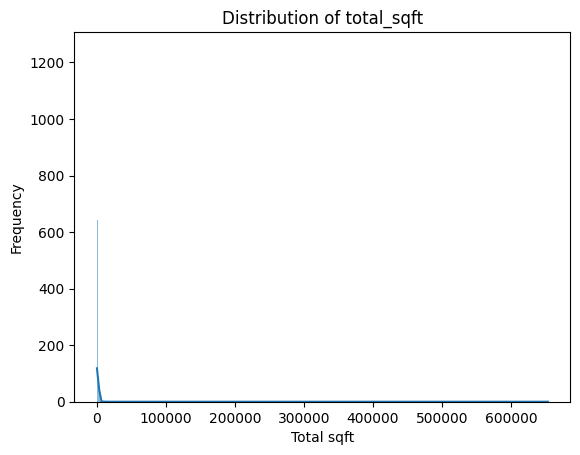

In [ ]:
sns.histplot(
    X_train["total_sqft"],
    kde=True
)

plt.xlabel("Total sqft")
plt.ylabel("Frequency")
plt.title("Distribution of total_sqft")
plt.show()

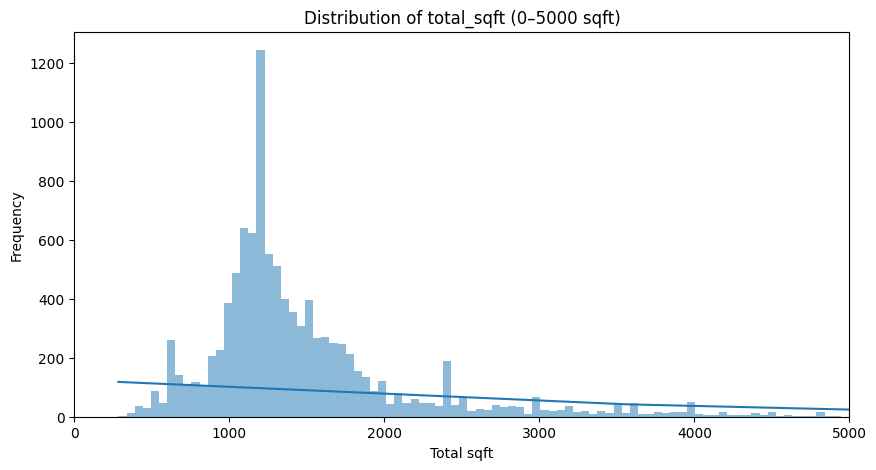

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    X_train["total_sqft"],
    kde=True
)

plt.xlim(0, 5000)
plt.xlabel("Total sqft")
plt.ylabel("Frequency")
plt.title("Distribution of total_sqft (0–5000 sqft)")
plt.show()

### bath

In [ ]:
bath_Q1 = X_train["bath"].quantile(0.25)
bath_Q3 = X_train["bath"].quantile(0.75)
bath_IQR = bath_Q3 - bath_Q1

bath_lower = bath_Q1 - 1.5 * bath_IQR
bath_upper = bath_Q3 + 1.5 * bath_IQR

bath_outliers = X_train[
    (X_train["bath"] < bath_lower) |
    (X_train["bath"] > bath_upper)
]

bath_outliers[
    ["bath", "bhk", "balcony", "total_sqft", "sqft_per_bhk",
     "area_type", "location"]
].sort_values("bath")

,bath,bhk,balcony,total_sqft,sqft_per_bhk,area_type,location
10910,5.0,5.0,2.0,3600.0,720.000000,Super built-up Area,rajaji nagar
10544,5.0,4.0,2.0,1000.0,250.000000,Plot Area,9th block jayanagar
6843,5.0,5.0,2.0,1000.0,200.000000,Plot Area,nyanappana halli
5984,5.0,4.0,1.0,3900.0,975.000000,Built-up Area,rahat bagh
2457,5.0,5.0,1.0,1440.0,288.000000,Plot Area,peenya
...,...,...,...,...,...,...,...
4916,15.0,14.0,0.0,1250.0,89.285714,Super built-up Area,1channasandra
3609,16.0,16.0,2.0,10000.0,625.000000,Super built-up Area,koramangala industrial layout
3379,16.0,19.0,2.0,2000.0,105.263158,Super built-up Area,1hanuman nagar
11559,18.0,18.0,2.0,1200.0,66.666667,Plot Area,1kasavanhalli


### bhk

In [ ]:
bhk_outliers = X_train[
    X_train["bhk"] > 4.5
]

bhk_outliers[
    ["bhk", "bath", "balcony", "total_sqft", "sqft_per_bhk",
     "area_type", "location"]
].sort_values("bhk")

,bhk,bath,balcony,total_sqft,sqft_per_bhk,area_type,location
3388,5.0,5.0,2.0,600.0,120.000000,Plot Area,jigani
8673,5.0,5.0,2.0,1000.0,200.000000,Plot Area,sahakara nagar
977,5.0,4.0,3.0,1640.0,328.000000,Plot Area,ramamurthy nagar
315,5.0,5.0,2.0,1200.0,240.000000,Plot Area,srirampura
3425,5.0,5.0,2.0,6200.0,1240.000000,Super built-up Area,ramakrishnappa layout
...,...,...,...,...,...,...,...
4916,14.0,15.0,0.0,1250.0,89.285714,Super built-up Area,1channasandra
3609,16.0,16.0,2.0,10000.0,625.000000,Super built-up Area,koramangala industrial layout
11559,18.0,18.0,2.0,1200.0,66.666667,Plot Area,1kasavanhalli
3379,19.0,16.0,2.0,2000.0,105.263158,Super built-up Area,1hanuman nagar


### sqft_bhk

In [ ]:
sqft_bhk_outliers = X_train[
    (X_train["sqft_per_bhk"] < 245.83) |
    (X_train["sqft_per_bhk"] > 852.50)
]

sqft_bhk_outliers[
    ["sqft_per_bhk", "total_sqft", "bhk", "bath",
     "balcony", "area_type", "location"]
].sort_values("sqft_per_bhk")

,sqft_per_bhk,total_sqft,bhk,bath,balcony,area_type,location
770,66.666667,600.0,9.0,9.0,3.0,Plot Area,sector 3 hsr layout
6813,66.666667,600.0,9.0,9.0,2.0,Plot Area,sector 2 hsr layout
11559,66.666667,1200.0,18.0,18.0,2.0,Plot Area,1kasavanhalli
45,75.000000,600.0,8.0,9.0,2.0,Plot Area,hsr layout
5071,75.000000,600.0,8.0,8.0,2.0,Plot Area,medahalli
...,...,...,...,...,...,...,...
6333,45520.200000,91040.4,2.0,2.0,0.0,Plot Area,harohalli
7726,54885.600000,54885.6,1.0,1.0,0.0,Plot Area,kanakpura road
7001,81675.000000,653400.0,8.0,6.0,2.0,Plot Area,thyagaraja nagar
11615,87120.000000,261360.0,3.0,2.0,0.0,Plot Area,arudi


## Removal

In [ ]:
numeric_cols = X_train.select_dtypes(include="number").columns

iqr_mask = pd.Series(True, index=X_train.index)

for col in numeric_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    col_mask = X_train[col].between(lower, upper)

    iqr_mask &= col_mask

In [ ]:
X_train_iqr = X_train[iqr_mask].copy()
y_train_iqr = y_train.loc[iqr_mask].copy()

In [ ]:
print("Original training size:", len(X_train))
print("After IQR removal:", len(X_train_iqr))
print("Rows removed:", len(X_train) - len(X_train_iqr))

Original training size: 10648
After IQR removal: 8884
Rows removed: 1764


## Model train

In [ ]:
X_train.isnull().sum()

,0
area_type,0
availability,0
location,0
total_sqft,0
bath,0
balcony,0
bhk,0
sqft_per_bhk,0


In [ ]:
X_train_iqr.isnull().sum()

,0
area_type,0
availability,0
location,0
total_sqft,0
bath,0
balcony,0
bhk,0
sqft_per_bhk,0


In [ ]:
X_train_iqr.drop(columns="sqft_per_bhk", inplace=True)

In [ ]:
X_train_iqr['area_type'].value_counts()

,count
area_type,
Super built-up Area,6481
Built-up Area,1595
Plot Area,745
Carpet Area,63


In [ ]:
X_train_iqr.columns

Index(['area_type', 'availability', 'location', 'total_sqft', 'bath',
       'balcony', 'bhk'],
      dtype='object')

In [ ]:
X_train_iqr['availability'].value_counts()

,count
availability,
Ready / Immediate Possession,6952
Date-based Possession,1932


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import TargetEncoder

# -------------------------
# Categorical pipelines
# -------------------------

availability_pipeline = Pipeline([
    # ("clean", availability_transformer),
    ("encoder", OneHotEncoder(handle_unknown="ignore",drop='first', sparse_output=False))
])

location_pipeline = Pipeline([
    ("clean", location_transformer),
    ("target_encoder", TargetEncoder(
        smooth="auto",
        target_type="continuous",
        random_state=42
    ))
])

In [ ]:
preprocessor2 = ColumnTransformer(
    transformers=[
        ("area_encoder", OneHotEncoder(drop='first',handle_unknown='ignore', sparse_output=False),['area_type']),
        ("availability", availability_pipeline, ["availability"]),
        ("location", location_pipeline, ["location"])
    ],
    remainder="passthrough"
)

preprocessor2.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('area_encoder',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['area_type']),
                                ('availability',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['availability']),
                                ('location',
                                 Pipeline(steps=[('clean',
                                                  FunctionTransformer(func=<function clean_location at 0x7b09d40813a0>)),
                                                 ('target_encoder',
                                                  TargetEncoder(random_state=42,
                                                                target_type='continuous'))]),
                                 ['location'])])

In [ ]:
preprocessor2.fit(X_train_iqr, y_train_iqr)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('area_encoder',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['area_type']),
                                ('availability',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['availability']),
                                ('location',
                                 Pipeline(steps=[('clean',
                                                  FunctionTransformer(func=<function clean_location at 0x7b09d40813a0>)),
                                                 ('target_encoder',
                                                  TargetEncoder(random_state=42,
                                                                target_type='continuous'))]),
                                 ['location'])])

In [ ]:
X_trans = preprocessor2.transform(X_train_iqr)
X_trans

,area_encoder__area_type_Carpet Area,area_encoder__area_type_Plot Area,area_encoder__area_type_Super built-up Area,availability__availability_Ready / Immediate Possession,location__location,remainder__total_sqft,remainder__bath,remainder__balcony,remainder__bhk
5208,0.0,0.0,1.0,1.0,75.447836,1460.0,2.0,2.0,3.0
8168,0.0,0.0,1.0,1.0,78.315283,1917.0,3.0,2.0,3.0
9687,0.0,0.0,1.0,1.0,33.285022,1319.0,3.0,1.0,3.0
4621,0.0,0.0,1.0,1.0,65.145227,1140.0,2.0,2.0,2.0
8298,0.0,0.0,1.0,0.0,86.743240,1232.0,2.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...
6272,0.0,1.0,0.0,1.0,95.000000,1200.0,1.0,2.0,2.0
11291,0.0,0.0,1.0,0.0,72.996267,1027.0,2.0,1.0,2.0
11972,0.0,0.0,1.0,1.0,67.092722,1101.0,2.0,2.0,2.0
5396,0.0,0.0,1.0,1.0,78.055757,1190.0,2.0,2.0,2.0


### LR

In [ ]:
from sklearn.linear_model import LinearRegression

model_pipeline = Pipeline([
    ("preprocessor", preprocessor2),
    ("m1", LinearRegression())
])

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_pipeline,
    X_train_iqr,
    y_train_iqr,
    cv=10,
    scoring="r2"
)

In [ ]:
cv_mean = cv_scores.mean()

print("R² scores:", cv_scores)
print("Mean CV R²:", cv_mean)

R² scores: [0.61578611 0.59992692 0.53259361 0.56028238 0.45379526 0.46353839
 0.57404577 0.50486721 0.61740056 0.59105858]
Mean CV R²: 0.5513294797756653


#### Assumptions of LR

##### linearity

In [ ]:
linear_model = model_pipeline.fit(
    X_train_iqr,
    y_train_iqr
)

y_train_pred = linear_model.predict(X_train_iqr)

In [ ]:
residuals = y_train_iqr - y_train_pred

In [ ]:
residuals.shape

(8884,)

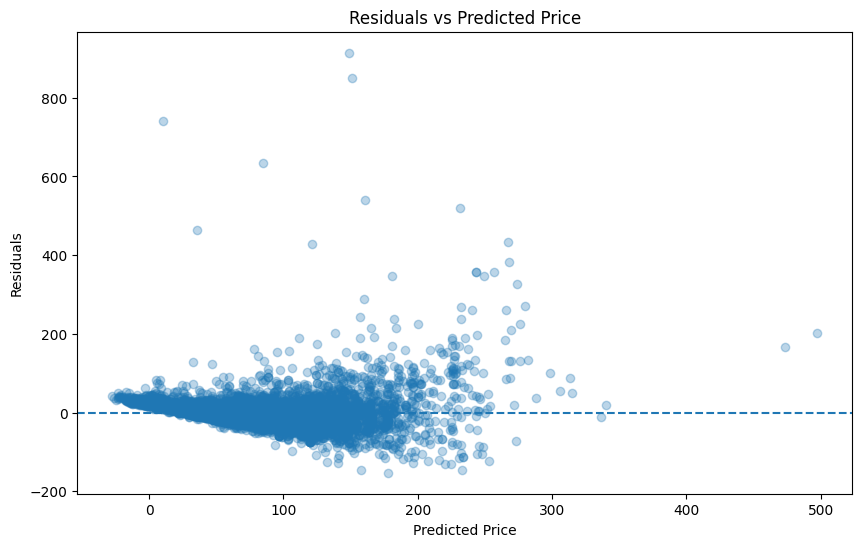

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    y_train_pred,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Price")

plt.show()

* The widening spread is more directly evidence of heteroscedasticity than of nonlinearity.

* The Linear Regression model is massively underpredicting some expensive properties.

##### **normality of residuals**

Normality of residuals is not a requirement for Linear Regression to make good predictions.

It mainly matters for statistical inference—confidence intervals, hypothesis tests, etc.


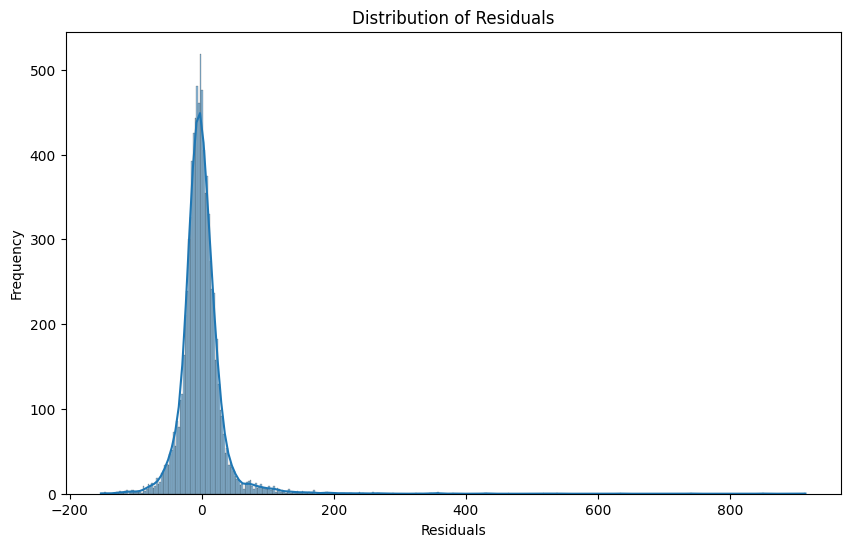

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

Residuals do not appear normally distributed.

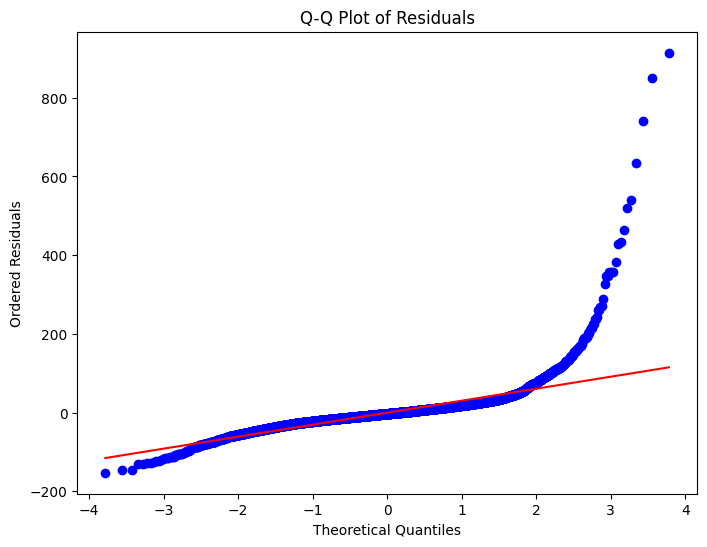

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(8, 6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Residuals")

plt.show()

The residuals significantly deviate from a normal distribution, especially in the right tail.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()

vif["Feature"] = X_trans.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_trans.values,
        i
    )
    for i in range(X_trans.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

,Feature,VIF
8,remainder__bhk,43.773139
6,remainder__bath,40.115391
5,remainder__total_sqft,35.481032
4,location__location,7.174119
7,remainder__balcony,6.249718
3,availability__availability_Ready / Immediate P...,4.216833
2,area_encoder__area_type_Super built-up Area,4.181207
1,area_encoder__area_type_Plot Area,1.615627
0,area_encoder__area_type_Carpet Area,1.032851


### DT

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# dt =  DecisionTreeRegressor(min_samples_split=20)

dt =  DecisionTreeRegressor(min_samples_split=2, min_samples_leaf=20, max_depth=10)

# {'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}

In [ ]:
from sklearn.model_selection import cross_val_score

dt_scores = cross_val_score(
    dt,
    X_trans,
    y_train_iqr,
    cv=10,
    scoring="r2"
)

In [ ]:
dt_mean = dt_scores.mean()

print("R² scores:", dt_scores)
print("Mean CV R²:", dt_mean)

R² scores: [0.70868848 0.68047913 0.71365946 0.72372878 0.50562769 0.54279042
 0.68500448 0.63050708 0.75879406 0.72458686]
Mean CV R²: 0.6673866436821311


In [ ]:
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeRegressor(
    random_state=42
)

param_grid = {
    "max_depth": [None, 5, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 5, 10, 20, 30, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20]
}

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=10,
    scoring="r2",
    n_jobs=-1
)

grid_search_dt.fit(
    X_trans,
    y_train_iqr
)

print("Best parameters:", grid_search_dt.best_params_)
print("Best CV R²:", grid_search_dt.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best CV R²: 0.6673866436821311


### XGBoost

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=70,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# xgb_model = XGBRegressor(
#     n_estimators=80,
#     learning_rate=0.01,
#     max_depth=3,
#     min_child_weight=1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     objective="reg:squarederror",
#     random_state=42,
#     n_jobs=-1
# )

# {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 80, 'model__subsample': 0.8}

In [ ]:
from sklearn.model_selection import cross_val_score

xg_scores = cross_val_score(
    xgb_model,
    X_trans,
    y_train_iqr,
    cv=10,
    scoring="r2"
)


In [ ]:
xg_mean = xg_scores.mean()

print("R² scores:", xg_scores)
print("Mean CV R²:", xg_mean)

R² scores: [0.74483998 0.75432566 0.73108007 0.77414507 0.53068466 0.55791875
 0.71744687 0.67787186 0.803762   0.73231552]
Mean CV R²: 0.7024390445588946


In [ ]:
xgb_param_grid = {
    "model__n_estimators": [80, 100, 200, 400],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=10,
    scoring="r2",
    n_jobs=-1
)

xgb_grid.fit(X_trans, y_train_iqr)

print("Best parameters:", xgb_grid.best_params_)
print("Best CV R²:", xgb_grid.best_score_)

Best parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 80, 'model__subsample': 0.8}
Best CV R²: 0.7024390445588946


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [12:30:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "model__colsample_bytree", "model__learning_rate", "model__max_depth", "model__min_child_weight", "model__n_estimators", "model__subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Knn

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# knn_pipeline = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", KNeighborsRegressor(
#         n_neighbors=40,
#         weights="distance",
#         metric="minkowski",
#         p=2
#     ))
# ])
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(
        n_neighbors=15,
        weights="uniform",
        metric="minkowski",
        p=1
    ))
])
# {'model__n_neighbors': 15, 'model__p': 1, 'model__weights': 'uniform'}

In [ ]:
from sklearn.model_selection import cross_val_score

knn_scores = cross_val_score(
    knn_pipeline,
    X_trans,
    y_train_iqr,
    cv=10,
    scoring="r2"
)

In [ ]:
knn_mean = knn_scores.mean()

print("R² scores:", knn_scores)
print("Mean CV R²:", knn_mean)

R² scores: [0.71538723 0.74179213 0.7219236  0.74762299 0.51324245 0.5462147
 0.69083238 0.63191906 0.78966528 0.72340329]
Mean CV R²: 0.6822003118028352


In [ ]:
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 10, 15, 20, 25, 30],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=10,
    scoring="r2",
    n_jobs=-1
)

knn_grid.fit(X_trans, y_train_iqr)

print("Best parameters:", knn_grid.best_params_)
print("Best CV R²:", knn_grid.best_score_)

Best parameters: {'model__n_neighbors': 15, 'model__p': 1, 'model__weights': 'uniform'}
Best CV R²: 0.6822003118028352


### KNN + DT

In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import cross_val_score

voting_knn_dt = VotingRegressor(
    estimators=[
        ("knn", knn_pipeline),
        ("dt", dt)
    ]
)

cv_scores_knn_dt = cross_val_score(
    voting_knn_dt,
    X_trans,
    y_train_iqr,
    cv=10,
    scoring="r2"
)

print("R² scores:", cv_scores_knn_dt)
print("Mean CV R²:", cv_scores_knn_dt.mean())

R² scores: [0.73458258 0.73729959 0.73880729 0.76536167 0.52858524 0.5627564
 0.71338713 0.6510629  0.79841193 0.74781666]
Mean CV R²: 0.6978071402232853


**Without tuning**

R² scores: [0.75725285 0.77717465 0.70177905 0.69171314 0.52713383 0.56872797
 0.74438814 0.66456653 0.80338526 0.719167  ]
Mean CV R²: 0.6955288416740076

### Knn + DT + XG

In [ ]:
voting_all = VotingRegressor(
    estimators=[
        ("knn", knn_pipeline),
        ("dt", dt),
        ("xgb", xgb_model)    ],
    weights=[1.5, 1, 3]
)

cv_scores_all = cross_val_score(
    voting_all,
    X_trans,
    y_train_iqr,
    cv=10,
    scoring="r2"
)

print("R² scores:", cv_scores_all)
print("Mean CV R²:", cv_scores_all.mean())

R² scores: [0.74986364 0.75631541 0.74454847 0.78257094 0.53512387 0.56662327
 0.72135543 0.6723149  0.80945896 0.74957018]
Mean CV R²: 0.708774504751689


**Without tunning**

R² scores: [0.76276957 0.77914278 0.72277189 0.74063676 0.53502091 0.57130657
 0.74454841 0.679651   0.81384766 0.73229537]
Mean CV R²: 0.7081990911475466

**With tunning**

R² scores: [0.74622825 0.74959389 0.74538392 0.77889019 0.53390022 0.56690022
 0.72005378 0.66657002 0.80652507 0.75238674]
Mean CV R²: 0.7066432296529559

**With weights = [1,1,2]** = R² scores: [0.74896613 0.75325894 0.74524009 0.78167918 0.53482702 0.56681349
 0.72139458 0.67185953 0.80820797 0.75102036]
Mean CV R²: 0.708326728873616

**With weights = [2,1,3]** = R² scores: [0.74955284 0.75726073 0.74457657 0.78242614 0.53502454 0.56672355
 0.72078842 0.67041368 0.80987906 0.74958043]
Mean CV R²: 0.7086225929772696

**With weights = [1.5,1,3]** = R² scores: [0.74986364 0.75631541 0.74454847 0.78257094 0.53512387 0.56662327
 0.72135543 0.6723149  0.80945896 0.74957018]
Mean CV R²: 0.708774504751689

### KNN + XG

In [ ]:
voting_knn_xg = VotingRegressor(
    estimators=[
        ("knn", knn_pipeline),
        ("xgb", xgb_model)    ],
    weights=[1, 2]
)

cv_scores_knn_xg = cross_val_score(
    voting_knn_xg,
    X_trans,
    y_train_iqr,
    cv=10,
    scoring="r2"
)

print("R² scores:", cv_scores_knn_xg)
print("Mean CV R²:", cv_scores_knn_xg.mean())

R² scores: [0.75000479 0.76156537 0.73980129 0.78138295 0.53399443 0.56418152
 0.71852353 0.67083713 0.81015394 0.74256335]
Mean CV R²: 0.707300829275981


# Model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import TargetEncoder


# -------------------------
# Numerical pipelines
# -------------------------

categorical_numerical_features = ['bhk', 'bath','balcony']
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
]
)
# -------------------------
# Categorical pipelines
# -------------------------

availability_pipeline = Pipeline([
    ("clean", availability_transformer),
    ("encoder", OneHotEncoder(handle_unknown="ignore",drop='first', sparse_output=False))
])

location_pipeline = Pipeline([
    ("clean", location_transformer),
    ("target_encoder", TargetEncoder(
        smooth="auto",
        target_type="continuous",
        random_state=42
    ))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("area_encoder", OneHotEncoder(drop='first',handle_unknown='ignore', sparse_output=False),['area_type']),

        ("availability", availability_pipeline, ["availability"]),
        ("location", location_pipeline, ["location"]),
        ("total_sqft", total_sqft_transformer, ["total_sqft"]),
        ('cat', categorical_transformer, categorical_numerical_features)
    ],
    remainder="drop"
)

preprocessor.set_output(transform='pandas')

ColumnTransformer(transformers=[('area_encoder',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['area_type']),
                                ('availability',
                                 Pipeline(steps=[('clean',
                                                  FunctionTransformer(func=<function clean_availability at 0x7a37a2ed0fe0>)),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['availability']...
                                                  FunctionTransformer(func=<function clean_location at 0x7a37a2ed1b20>)),
                                                 ('target_encoder',
                                                  TargetEncoder(random_state=42,
                                                                target_type='continuous'))]),
                                 ['location']),
                                ('total_sqft',
                                 FunctionTransformer(func=<function clean_total_sqft at 0x7a37abc1ce00>),
                                 ['total_sqft']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['bhk', 'bath', 'balcony'])])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import VotingRegressor

voting_all = VotingRegressor(
    estimators=[
        ("knn", knn_pipeline),
        ("dt", dt),
        ("xgb", xgb_model)],
    weights=[2, 1, 3]
)

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", voting_all)
])

In [ ]:
iqr_indices = iqr_mask[iqr_mask].index
len(iqr_indices)

8884

In [ ]:
X_trainf = data.loc[iqr_indices].drop(columns="price")
y_trainf = data.loc[iqr_indices, "price"]

In [ ]:
X_testf = data.loc[X_test.index].drop(columns="price")
y_testf = data.loc[X_test.index, "price"]

In [ ]:
preprocessor.fit(X_trainf,y_trainf)

ColumnTransformer(transformers=[('area_encoder',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['area_type']),
                                ('availability',
                                 Pipeline(steps=[('clean',
                                                  FunctionTransformer(func=<function clean_availability at 0x7eb6f9773ce0>)),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['availability']...
                                                  FunctionTransformer(func=<function clean_location at 0x7eb6f97b8a40>)),
                                                 ('target_encoder',
                                                  TargetEncoder(random_state=42,
                                                                target_type='continuous'))]),
                                 ['location']),
                                ('total_sqft',
                                 FunctionTransformer(func=<function clean_total_sqft at 0x7eb6fe233920>),
                                 ['total_sqft']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['bhk', 'bath', 'balcony'])])

In [ ]:
X_transformed = preprocessor.transform(X_trainf)
X_transformed

,area_encoder__area_type_Carpet Area,area_encoder__area_type_Plot Area,area_encoder__area_type_Super built-up Area,availability__availability_Ready / Immediate Possession,location__location,total_sqft__total_sqft,cat__bhk,cat__bath,cat__balcony
5208,0.0,0.0,1.0,1.0,75.447836,1460.0,3.0,2.0,2.0
8168,0.0,0.0,1.0,1.0,78.315283,1917.0,3.0,3.0,2.0
9687,0.0,0.0,1.0,1.0,33.285022,1319.0,3.0,3.0,1.0
4621,0.0,0.0,1.0,1.0,65.145227,1140.0,2.0,2.0,2.0
8298,0.0,0.0,1.0,0.0,86.743240,1232.0,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...
6272,0.0,1.0,0.0,1.0,95.000000,1200.0,2.0,1.0,2.0
11291,0.0,0.0,1.0,0.0,72.996267,1027.0,2.0,2.0,1.0
11972,0.0,0.0,1.0,1.0,67.092722,1101.0,2.0,2.0,2.0
5396,0.0,0.0,1.0,1.0,78.055757,1190.0,2.0,2.0,2.0


In [ ]:
X_trans

NameError: name 'X_trans' is not defined

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_pipeline,
    data.loc[X_train.index].drop(columns="price"),
    data.loc[X_train.index,"price"],
    cv=10,
    scoring="r2"
)

In [ ]:
cv_mean = cv_scores.mean()

print("R² scores:", cv_scores)
print("Mean CV R²:", cv_mean)
print("Std. Dev. of CV R²:", cv_scores.std())

R² scores: [0.68724328 0.68591133 0.6128547  0.53303783 0.45027094 0.70411618
 0.67723665 0.67597332 0.60419668 0.6292737 ]
Mean CV R²: 0.6260114621309837
Std. Dev. of CV R²: 0.07664616042679309


**Outlier removed**

R² scores: [0.66446893 0.68143454 0.7088591  0.73514423 0.47728738 0.52865927
 0.65153096 0.61739431 0.75715623 0.66485194]
Mean CV R²: 0.6486786881357594
Std. Dev. of CV R²: 0.08319596688766762

**voting_all**

R² scores: [0.68724328 0.68591133 0.6128547  0.53303783 0.45027094 0.70411618
 0.67723665 0.67597332 0.60419668 0.6292737 ]
Mean CV R²: 0.6260114621309837
Std. Dev. of CV R²: 0.07664616042679312

**xgb_model**

R² scores: [0.76001717 0.69794081 0.67263085 0.56766328 0.46529225 0.72399865
 0.69436101 0.69112105 0.47673095 0.63147403]
Mean CV R²: 0.6381230045963119
Std. Dev. of CV R²: 0.09690197680914656


In [ ]:
model_pipeline.fit(data.loc[X_train.index].drop(columns="price"), data.loc[X_train.index,"price"])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('area_encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['area_type']),
                                                 ('availability',
                                                  Pipeline(steps=[('clean',
                                                                   FunctionTransformer(func=<function clean_availability at 0x7a37a2ed0fe0>)),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_o...
                                                           gamma=None,
                                                           grow_policy=None,
                                                           importance_type=None,
                                                           interaction_constraints=None,
                                                           learning_rate=0.05,
                                                           max_bin=None,
                                                           max_cat_threshold=None,
                                                           max_cat_to_onehot=None,
                                                           max_delta_step=None,
                                                           max_depth=6,
                                                           max_leaves=None,
                                                           min_child_weight=1,
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=70,
                                                           n_jobs=-1,
                                                           num_parallel_tree=None, ...))],
                                 weights=[2, 1, 3]))])

In [ ]:
import joblib

joblib.dump(model_pipeline, "house_price_model.pkl")

['house_price_model.pkl']

In [ ]:
y_pred = model_pipeline.predict(X_testf)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_testf, y_pred)
mae = mean_absolute_error(y_testf, y_pred)
rmse = np.sqrt(mean_squared_error(y_testf, y_pred))

print("Test R²  :", r2)
print("Test MAE :", mae)
print("Test RMSE:", rmse)

Test R²  : 0.6242799844445608
Test MAE : 32.25575015021951
Test RMSE: 92.28493625952662


**fit on outlier removed**

Test R²  : 0.42446284830500425
Test MAE : 31.941607607433955
Test RMSE: 102.18555609565104

**Without outlier removed**

Test R²  : 0.717127632777875
Test MAE : 29.585651286358008
Test RMSE: 71.63876553568579

**voting_all**

Test R²  : 0.6242799844445608
Test MAE : 32.25575015021951
Test RMSE: 92.28493625952662

**xgb_model**

Test R²  : 0.6359059434997698
Test MAE : 31.510502845686805
Test RMSE: 90.84592379545121

## Evaluation

In [ ]:
print("Training target:")
print(y_trainf.describe())

print("\nTest target:")
print(y_testf.describe())

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(y_trainf, bins=50, alpha=0.5, label="Train")
plt.hist(y_testf, bins=50, alpha=0.5, label="Test")

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Train vs Test Target Distribution")
plt.legend()

plt.show()